# PINN求解Burgers方程

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import time

from sklearn.metrics import mean_squared_error, mean_absolute_error


plt.rcParams['font.sans-serif']=['Times New Roman'] #设置默认字体
plt.rcParams['axes.unicode_minus']=False

np.random.seed(1234)
torch.manual_seed(1234)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('running on: %s'%(device))

# 输出路径
base_dir = os.getcwd()
print(f"Current working directory: {base_dir}")
# base_dir = os.path.dirname(os.path.abspath(__file__))
output_path = os.path.join(base_dir, 'Hom2', 'Output', 'PINN_pred.mat')


# 参考解
file = loadmat('Hom2\\burgers_shock.mat')
base_x = file['x']
base_t = file['t']
base_u = file['usol']
print('x_size:', base_x.shape, 't_size:', base_t.shape, 'u_size:', base_u.shape)

running on: cuda
Current working directory: d:\MyDocs\Workspace\SciML_Course_Homework
x_size: (256, 1) t_size: (100, 1) u_size: (256, 100)


In [2]:
# 转 tensor
def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32)

# 截取不同时刻
def part_t(x=np.linspace(-1, 1, 256), 
           t=np.linspace(0,0.9,100),
           u=None, 
           time_slices=[0, 0.2, 0.4, 0.6, 0.8]):
    t=t.flatten()
    id_t = []
    for j in time_slices:
        id = np.argwhere(t==j).flatten()
        id_t += id.tolist()
    u_slices = u[:,id_t]
    print(u_slices.shape)
    return u_slices

In [3]:
# 预测函数
def predict(model, x, t):
    X, T = np.meshgrid(x, t)

    XT = np.hstack([X.flatten()[:,None], T.flatten()[:,None]])
    XT = to_tensor(XT)

    U_pred = model(XT).detach().numpy()
    return U_pred.reshape(len(t), len(x))

## 可视化函数

In [4]:
# 二维等高线
def plot_sol_2d(model=None, x=np.linspace(-1, 1, 256), 
                t=np.linspace(0, 0.9, 100), u=None, title=None):
    X, T = np.meshgrid(x, t)
    U = predict(model, x, t) if u is None and model is not None else u

    plt.figure(figsize=(6, 4))
    plt.contourf(T, X, U, 100, cmap='viridis')
    plt.colorbar()
    plt.xlabel('t')
    plt.ylabel('x')
    plt.title(title)
    plt.show()

# 三维曲面图
def plot_sol_3d(model=None, x=np.linspace(-1, 1, 256), 
                t=np.linspace(0, 0.9, 100), u=None):
    X, T = np.meshgrid(x, t)
    U = predict(model, x, t) if u is None and model is not None else u
    
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, T, U, cmap='viridis')

    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u(t, x)')
    ax.set_title('Solution of Burgers Equation on (x, t) Plane')
    plt.show()

# 不同t时刻(x,u)截面
def plot_sol_curve(model=None, 
                   x=np.linspace(-1, 1, 256), 
                   t=np.linspace(-1, 0.9, 100), 
                   u=None, 
                   time_slices=[0, 0.2, 0.4, 0.6, 0.8],
                   label=None):  #时间切片
    
    if len(time_slices) >= 2:
        plt.figure(figsize=(6, 4))
        # 添加初始条件作为参考（t=0时的精确解）
        u_initial = -np.sin(np.pi * x)
        plt.plot(x, u_initial, 'k:', label='Exact t=0', linewidth=2, alpha=0.7)
        

    if u is None and model is not None:

        for i, t_val in enumerate(time_slices):
            # 为当前时间切片创建输入数据
            t_vals = np.full_like(x, t_val)[:, None]
            XT_slice = np.hstack((x[:, None], t_vals))
            XT_tensor = to_tensor(XT_slice)
            # 获取模型预测
            u_pred = model(XT_tensor).detach().numpy()
        
            # 绘制当前时间切片的曲线
            plt.plot(x, u_pred, 
                    label=f't={t_val}' if label is None else label, 
                    linewidth=2)
    
    else:
        u_pred = part_t(x=x, t=t, u=u,time_slices=time_slices)
        for i, t_val in enumerate(time_slices):
            part_u = u_pred[:,i]
            plt.plot(x, part_u, 
                    label=f't={t_val}' if label is None else label, 
                    linewidth=2)
        

    # 设置图形属性
    plt.xlabel("x", fontsize=14)
    plt.ylabel("u(t,x)", fontsize=14)
    plt.title("Burgers Equation at "+", ".join(map(str,time_slices)))
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.15)
    plt.xlim([-1, 1])
    # plt.tight_layout()
    if len(time_slices) >=2:
        plt.show()



## 参考解图像

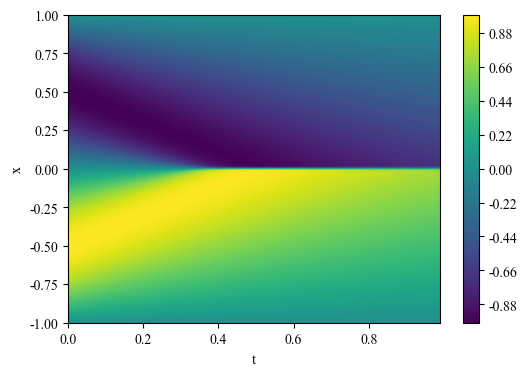

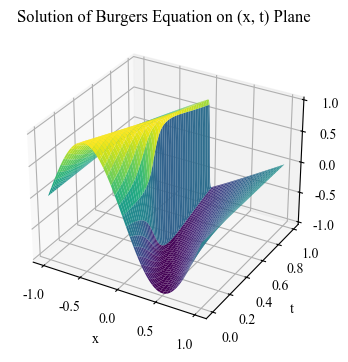

(256, 5)


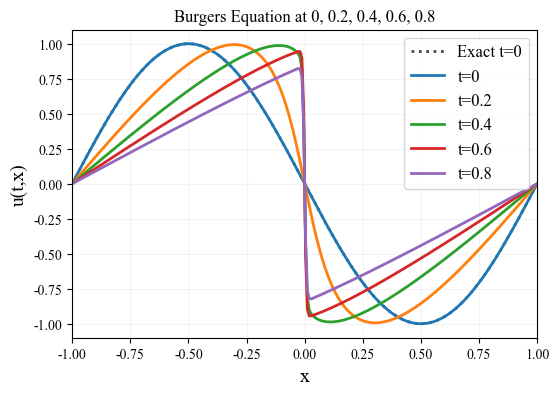

In [5]:
plot_sol_2d(x=base_x, t=base_t, u=base_u.T)
plot_sol_3d(x=base_x, t=base_t, u=base_u.T)
plot_sol_curve(x=base_x, t=base_t, u=base_u)

## PINN搭建

In [6]:
class PINN(nn.Module):
    def __init__(self, layers=[2,30,30,1]):
        super(PINN, self).__init__()
        L = len(layers)
        self.layers = layers
        self.activation = nn.Tanh()

        self.linears = nn.ModuleList()
        for i in range(1, L):
            layer = nn.Linear(layers[i-1], layers[i])
            self.linears.append(layer)
            
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)


    def forward(self, x):
        A = x
        for i in range(len(self.linears) - 1):
            A = self.activation(self.linears[i](A))

        Y = self.linears[-1](A)
        return Y
    

    def pdenn(self, x, t, nu=0.01/np.pi):
        x = x.clone().detach().requires_grad_(True)
        t = t.clone().detach().requires_grad_(True)

        u = self.forward(torch.cat([x,t], dim=1))

        u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
        u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]

        f = u_t + u*u_x - nu*u_xx
        return f


## 初始与边界条件

In [7]:
# 初始条件
def ic(x):
    return -np.sin(np.pi * x)
# 边界条件
def bc(t):
    return np.zeros_like(t)

## 数据采样

In [8]:
# 参数
nu = 0.01 / np.pi

# 随机采样
def training_data(N_f=8000, N_bc=200, N_ic=200):
    # PDE点（内部）
    x_f = np.random.uniform(-1, 1, (N_f, 1))
    t_f = np.random.uniform(0, 0.9, (N_f, 1))

    # 初始条件 t=0
    x_ic = np.random.uniform(-1, 1, (N_ic, 1))
    t_ic = np.zeros_like(x_ic)
    u_ic = ic(x_ic)

    # 边界条件 x=-1,1
    t_bc = np.random.uniform(0, 0.9, (N_bc, 1))

    x_bc_l = -np.ones((N_bc, 1))
    x_bc_r = np.ones((N_bc, 1))
    u_bc = bc(t_bc)

    x_bc = np.vstack([x_bc_l, x_bc_r])
    t_bc = np.vstack([t_bc, t_bc])
    u_bc = np.vstack([u_bc, u_bc])
    # u_bc = np.zeros_like(x_bc)

    return x_f, t_f, x_ic, t_ic, u_ic, x_bc, t_bc, u_bc

# 自适应加点
def add_data(model, N_new=500):
    x_f = np.random.uniform(-1, 1,(N_new,1))
    t_f = np.random.uniform(0,0.9, (N_new,1))

    x_f = to_tensor(x_f).to(device)
    t_f = to_tensor(t_f).to(device)

    f = model.pdenn(x_f, t_f, nu=0.01/np.pi)
    err = np.abs(f.detach().cpu().numpy())

    idx = np.argsort(err[:,0])[-100:]
    x_add = x_f[idx]
    t_add = t_f[idx]
    return x_add, t_add


## 模型训练

In [9]:

def train_model(rar=False, layers=[2,30,30,1], nmax=30000):
    # 数据
    if rar :
        print('当前采样方式：RAR')
    datas = training_data() if rar==False else training_data(N_f=2000)
    datas_tensor = map(to_tensor, datas)
    datas_device = map(lambda x: x.to(device), datas_tensor)
    x_f, t_f, x_ic, t_ic, u_ic, x_bc, t_bc, u_bc = datas_device

    # 模型
    model =PINN(layers).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    mse = nn.MSELoss()

    # 损失值存储
    ls_loss_f = []
    ls_loss_ic = []
    ls_loss_bc = []
    loss_results = []
    added_points={'x':[],'t':[]}

    # 训练
    start_time = time.perf_counter()
    for n in range(nmax+1):
        # RAR加点
        if rar and n%500 ==0:
            x_add, t_add = add_data(model)
            
            added_points['x'] += x_add.detach().cpu().numpy().flatten().tolist()
            added_points['t'] += t_add.detach().cpu().numpy().flatten().tolist()

            x_add = to_tensor(x_add)
            t_add = to_tensor(t_add)
            x_f = torch.cat([x_f, x_add], dim=0)
            t_f = torch.cat([t_f, t_add], dim=0)
            print('# of training data: %d'%(x_f.shape[0]))

        optimizer.zero_grad()

        # PDE损失
        f_pred = model.pdenn(x_f, t_f, nu=0.01/np.pi)
        loss_f = mse(f_pred, torch.zeros_like(f_pred))

        # 初始条件
        u_ic_pred = model(torch.cat([x_ic, t_ic], dim=1))
        loss_ic = mse(u_ic_pred, u_ic)

        # 边界条件
        u_bc_pred = model(torch.cat([x_bc, t_bc], dim=1))
        loss_bc = mse(u_bc_pred, u_bc)

        loss = loss_f + loss_ic + loss_bc

        loss.backward()
        optimizer.step()

        if n % 500 == 0:
            print(f"epoch {n}, Loss: {loss.item():.3e}")
            ls_loss_f.append(loss_f.item())
            ls_loss_ic.append(loss_ic.item())
            ls_loss_bc.append(loss_bc.item())
            loss_results.append(loss.item())

    
    stop_time = time.perf_counter()
    print('Duration time is %.3f seconds'%(stop_time - start_time))

    return model.cpu(), ls_loss_f, ls_loss_ic, ls_loss_bc, loss_results, added_points

default_nmax = train_model.__defaults__[2]
default_n = np.array([i for i in range(0,default_nmax+1,500)])

In [10]:
def rar_model(layers=[2,30,30,1]):
    # 初始数据
    datas = training_data(N_f=2000)
    datas_tensor = map(to_tensor, datas)
    datas_device = map(lambda x: x.to(device), datas_tensor)
    x_f, t_f, x_ic, t_ic, u_ic, x_bc, t_bc, u_bc = datas_device

    def build_dataset(x, x_add):
        return torch.cat([x, x_add], dim=0)

    # 模型
    model = PINN(layers).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    mse = nn.MSELoss()

    n=0
    nmax = 5
    err = 1.

    n_r_max = 2000

    start_time = time.perf_counter()
    while n <= nmax and err > 1.0e-4:
        print()
        print('Loop: %d'%(n+1))
        if n == 0:
            x_f = x_f
            x_f = t_f
        else:
            x_f = build_dataset(x_f, x_add)
            t_f = build_dataset(t_f, t_add)

        n_r = 0
        loss = 1.0

        # 训练
        while n_r <= n_r_max and loss >= 1.03-6:
            optimizer.zero_grad()

            # PDE损失
            f_pred = model.pdenn(x_f, t_f, nu=0.01/np.pi)
            loss_f = mse(f_pred, torch.zeros_like(f_pred))

            # 初始条件
            u_ic_pred = model(torch.cat([x_ic, t_ic], dim=1))
            loss_ic = mse(u_ic_pred, u_ic)

            # 边界条件
            u_bc_pred = model(torch.cat([x_bc, t_bc], dim=1))
            loss_bc = mse(u_bc_pred, u_bc)

            loss = loss_f + loss_ic + loss_bc

            loss.backward()
            optimizer.step()

            n_r += 1
            if n_r%100 == 0:
                print('Steps: %d, Loss: %.3e'%(n_r, loss))
        n += 1
        
        print('# of training data: %d'%(x_f.shape[0]))

        err = np.mean(np.absolute(f_pred.detach().cpu().numpy()))
        print('Mean error of residual: %.5f'%(err))

        # 自适应加点
        x_add, t_add = add_data(model)
        x_add = to_tensor(x_add)
        t_add = to_tensor(t_add)

        print(f"Loss after training: {loss.item():.3e}")

    stop_time = time.perf_counter()
    print('Duration time is %.3f seconds'%(stop_time - start_time))

    return model.cpu()

## 损失函数可视化

In [11]:
# ===损失函数可视化===
loss_name = ['loss_f', 'loss_ic', 'loss_bc', 'total_loss']

def plot_loss(loss, title='Training Loss Curve'):
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(default_n, loss)

    ax.set_yscale('log')
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
    ax.yaxis.set_minor_locator(ticker.NullLocator())

    ax.xaxis.set_major_locator(ticker.MultipleLocator(5000))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(2500))

    # formatter = ticker.ScalarFormatter(useMathText=True)
    # formatter.set_powerlimits((4,4))
    # ax.xaxis.set_major_formatter(formatter)

    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.grid(ls='-', alpha=0.15)
    plt.title(title)
    plt.legend()
    plt.show()

def plot_loss_dict(loss_dict, title='Training Loss Curve'):
    fig, ax = plt.subplots(figsize=(6,4))
    for key, loss in loss_dict.items():
        ax.plot(default_n, loss, label=key)

    ax.set_yscale('log')
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
    ax.yaxis.set_minor_locator(ticker.NullLocator())

    ax.xaxis.set_major_locator(ticker.MultipleLocator(5000))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(2500))

    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.grid(ls='-', alpha=0.15)
    plt.title(title)
    plt.legend()
    plt.show()



## 模型评估

In [12]:
# ===模型评估===

def evaluate(model):
    x_test = torch.tensor(base_x, dtype=torch.float32)
    t_test = torch.tensor(base_t, dtype=torch.float32)
    U_pred = predict(model, x_test, t_test)

    mse = mean_squared_error(base_u.T, U_pred)
    mae = mean_absolute_error(base_u.T, U_pred)

    return U_pred, mse, mae

## 实验结果

### 随机采样

In [13]:
pro = train_model()

d:\Software\Python\Python\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch 0, Loss: 4.668e-01
epoch 500, Loss: 1.285e-01
epoch 1000, Loss: 1.010e-01
epoch 1500, Loss: 8.988e-02
epoch 2000, Loss: 8.486e-02
epoch 2500, Loss: 8.105e-02
epoch 3000, Loss: 7.682e-02
epoch 3500, Loss: 7.223e-02
epoch 4000, Loss: 6.787e-02
epoch 4500, Loss: 6.449e-02
epoch 5000, Loss: 6.231e-02
epoch 5500, Loss: 6.034e-02
epoch 6000, Loss: 5.805e-02
epoch 6500, Loss: 5.575e-02
epoch 7000, Loss: 5.174e-02
epoch 7500, Loss: 4.932e-02
epoch 8000, Loss: 4.788e-02
epoch 8500, Loss: 4.692e-02
epoch 9000, Loss: 4.618e-02
epoch 9500, Loss: 4.553e-02
epoch 10000, Loss: 4.491e-02
epoch 10500, Loss: 4.423e-02
epoch 11000, Loss: 4.340e-02
epoch 11500, Loss: 4.238e-02
epoch 12000, Loss: 4.122e-02
epoch 12500, Loss: 3.992e-02
epoch 13000, Loss: 3.863e-02
epoch 13500, Loss: 3.870e-02
epoch 14000, Loss: 3.595e-02
epoch 14500, Loss: 3.448e-02
epoch 15000, Loss: 3.301e-02
epoch 15500, Loss: 3.166e-02
epoch 16000, Loss: 3.043e-02
epoch 16500, Loss: 2.992e-02
epoch 17000, Loss: 2.837e-02
epoch 175

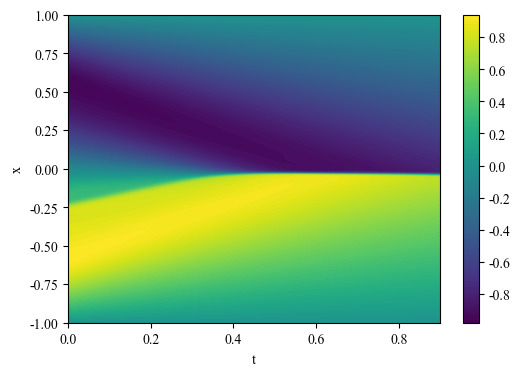

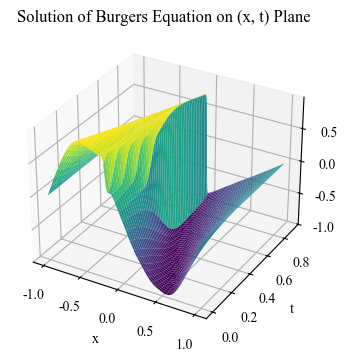

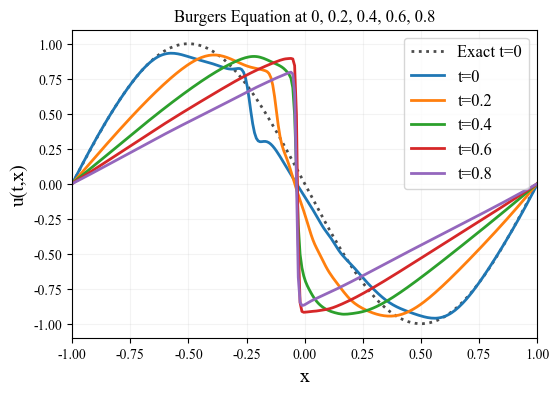

In [14]:
model = pro[0]

## 预测结果可视化
plot_sol_2d(model)
plot_sol_3d(model)
plot_sol_curve(model)

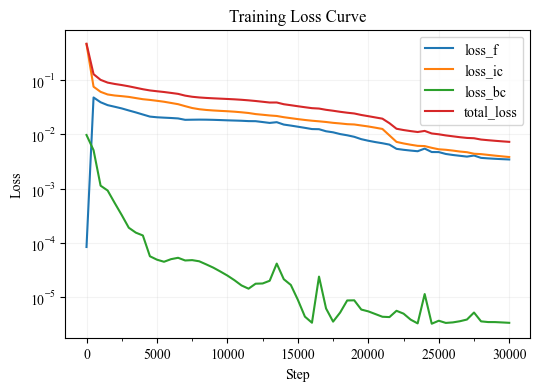

In [15]:
# 损失曲线图

loss = pro[1:-1]
loss_dict = dict(zip(loss_name,loss))

plot_loss_dict(loss_dict)

mse_pde:1.98259e-02, mae_pde:4.09038e-02


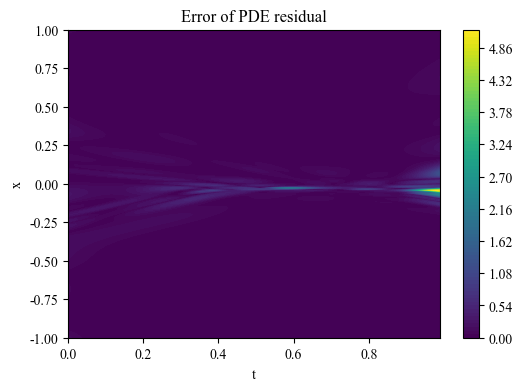

In [16]:
# 残差热力图

x_test, t_test = base_x, base_t
X_, T_ = np.meshgrid(x_test,t_test)
X_, T_ = X_.reshape(-1,1), T_.reshape(-1,1)

f_pred = model.pdenn(to_tensor(X_),to_tensor(T_)).detach()

mse_pde = mean_squared_error(f_pred, torch.zeros_like(f_pred))
mae_pde = mean_absolute_error(f_pred, torch.zeros_like(f_pred))
print(f'mse_pde:{mse_pde:.5e}, mae_pde:{mae_pde:.5e}')

f_pred = np.abs(f_pred.reshape(len(t_test),len(x_test)).numpy())

plot_sol_2d(x=x_test, t=t_test, u=f_pred,title='Error of PDE residual')

(100, 256)
MSE:2.86210e-02, MAE:4.04942e-02


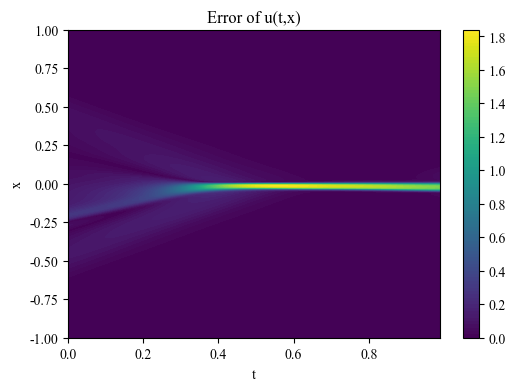

In [17]:
# 与参考数据对比

u_pred, mse, mae = evaluate(model)
print(u_pred.shape)
print(f"MSE:{mse:.5e}, MAE:{mae:.5e}")

err = np.abs(u_pred-base_u.T)
plot_sol_2d(x=base_x, t=base_t, u=err, title='Error of u(t,x)')

### 自适应加点

In [18]:
pro_rar = train_model(rar=True)

当前采样方式：RAR
# of training data: 2100
epoch 0, Loss: 5.921e-01


C:\Users\xin\AppData\Local\Temp\ipykernel_28088\2558606513.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=torch.float32)


# of training data: 2200
epoch 500, Loss: 1.407e-01
# of training data: 2300
epoch 1000, Loss: 1.199e-01
# of training data: 2400
epoch 1500, Loss: 1.051e-01
# of training data: 2500
epoch 2000, Loss: 9.634e-02
# of training data: 2600
epoch 2500, Loss: 9.047e-02
# of training data: 2700
epoch 3000, Loss: 8.462e-02
# of training data: 2800
epoch 3500, Loss: 8.096e-02
# of training data: 2900
epoch 4000, Loss: 7.692e-02
# of training data: 3000
epoch 4500, Loss: 7.253e-02
# of training data: 3100
epoch 5000, Loss: 6.712e-02
# of training data: 3200
epoch 5500, Loss: 5.425e-02
# of training data: 3300
epoch 6000, Loss: 4.862e-02
# of training data: 3400
epoch 6500, Loss: 4.543e-02
# of training data: 3500
epoch 7000, Loss: 4.372e-02
# of training data: 3600
epoch 7500, Loss: 4.245e-02
# of training data: 3700
epoch 8000, Loss: 4.842e-02
# of training data: 3800
epoch 8500, Loss: 3.906e-02
# of training data: 3900
epoch 9000, Loss: 3.764e-02
# of training data: 4000
epoch 9500, Loss: 3.62

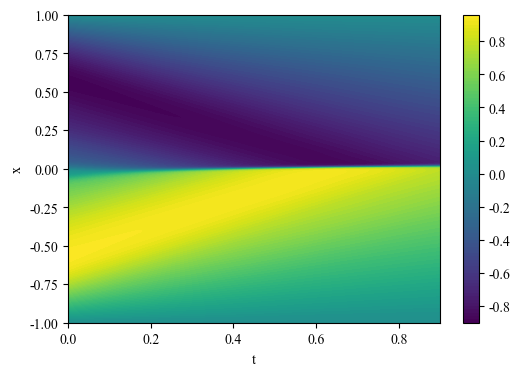

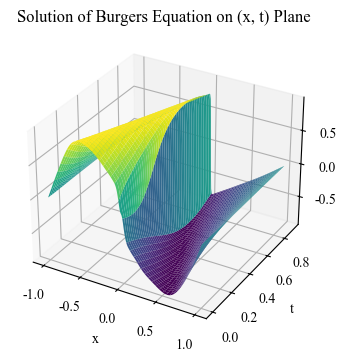

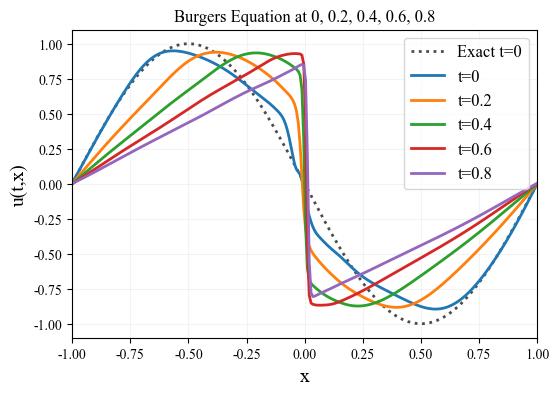

In [19]:
model_rar = pro_rar[0]

## 预测结果可视化
plot_sol_2d(model_rar)
plot_sol_3d(model_rar)
plot_sol_curve(model_rar)

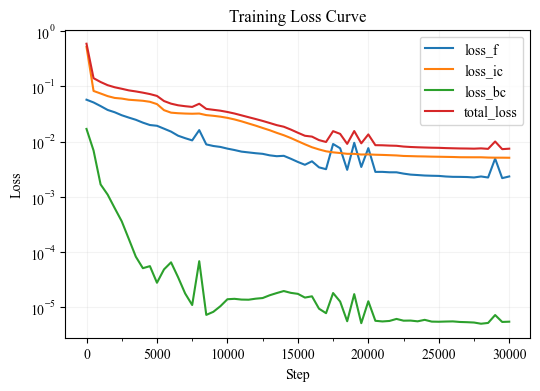

In [20]:
# 损失曲线图

loss_rar = pro_rar[1:-1]
loss_rar_dict = dict(zip(loss_name,loss_rar))

plot_loss_dict(loss_rar_dict)

<class 'float'>


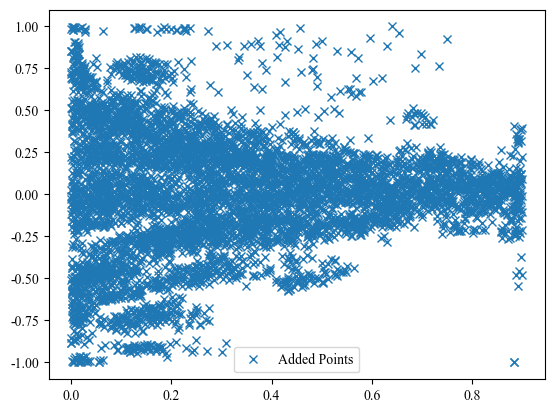

In [21]:
# 添加的残差点图像

added_x, added_t = pro_rar[-1]['x'], pro_rar[-1]['t']
added_x
print(type(added_x[0]))
plt.figure()
plt.plot(added_t, added_x, marker='x',linestyle='None', label='Added Points')
plt.legend()
plt.show()

mse_pde:9.58060e-03, mae_pde:3.07449e-02


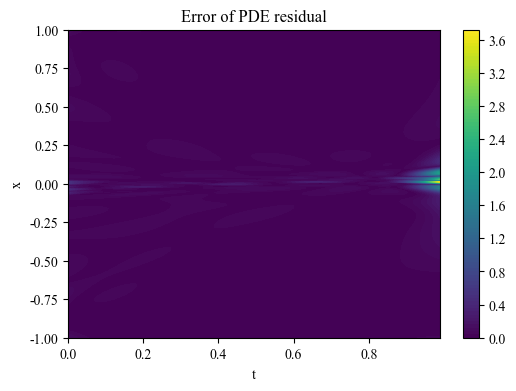

In [22]:
# 残差热力图

x_test, t_test = base_x, base_t
X_, T_ = np.meshgrid(x_test,t_test)
X_, T_ = X_.reshape(-1,1), T_.reshape(-1,1)

f_pred_rar = model_rar.pdenn(to_tensor(X_),to_tensor(T_)).detach()

mse_pde_rar = mean_squared_error(f_pred_rar, torch.zeros_like(f_pred_rar))
mae_pde_rar = mean_absolute_error(f_pred_rar, torch.zeros_like(f_pred_rar))
print(f'mse_pde:{mse_pde_rar:.5e}, mae_pde:{mae_pde_rar:.5e}')

f_pred_rar = np.abs(f_pred_rar.reshape(len(t_test),len(x_test)).numpy())

plot_sol_2d(x=x_test, t=t_test, u=f_pred_rar,title='Error of PDE residual')

(100, 256)
MSE:6.75816e-03, MAE:3.04283e-02


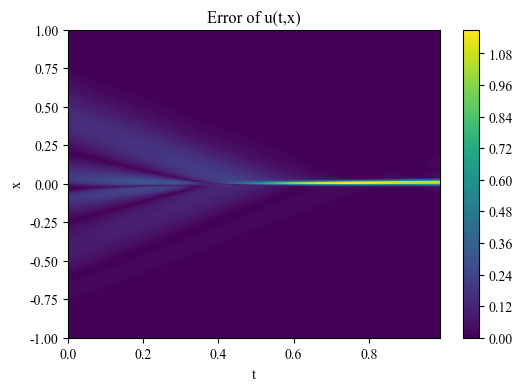

In [23]:
# 与参考数据对比
u_rar_pred, mse_rar, mae_rar = evaluate(model_rar)
print(u_rar_pred.shape)
print(f"MSE:{mse_rar:.5e}, MAE:{mae_rar:.5e}")


err_rar = np.abs(u_rar_pred-base_u.T)
plot_sol_2d(x=base_x, t=base_t, u=err_rar, title='Error of u(t,x)')

(256, 1)


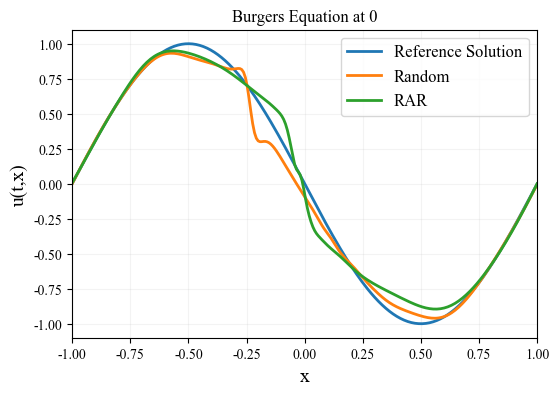

(256, 1)


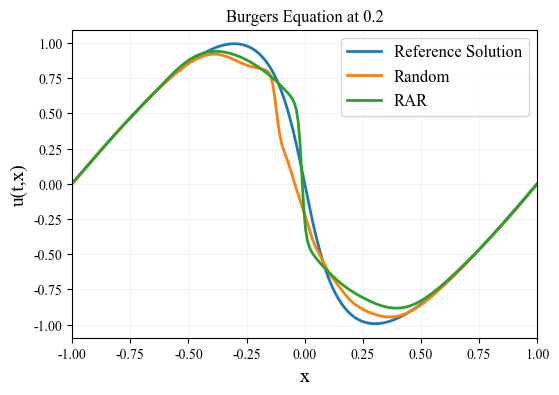

(256, 1)


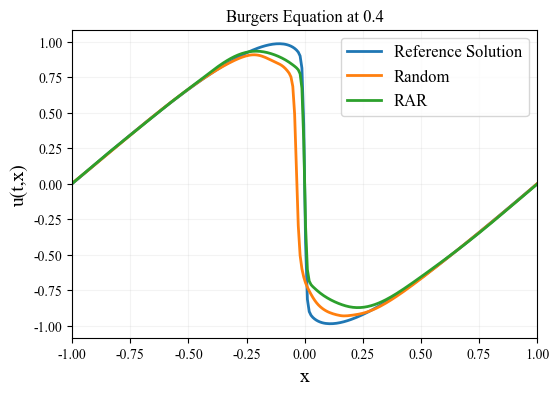

(256, 1)


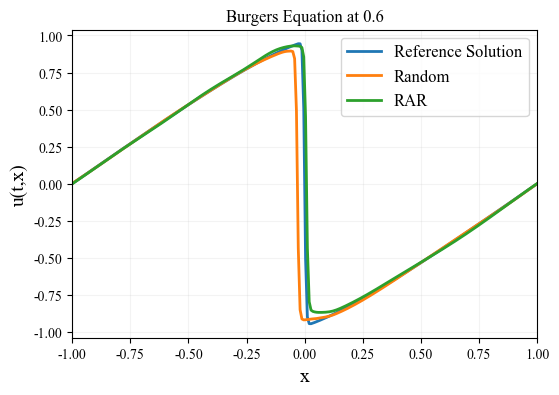

(256, 1)


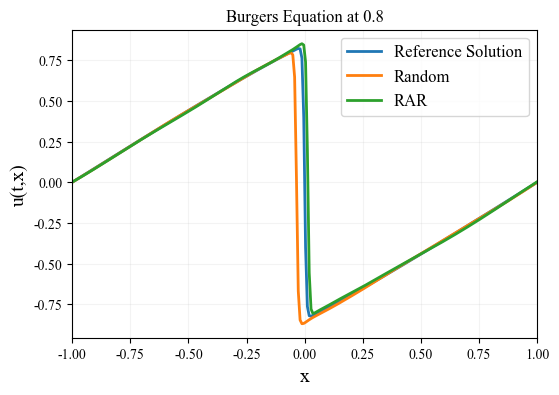

In [24]:
# 三组样本不同时刻对比

time_slices=[0, 0.2, 0.4, 0.6, 0.8]
for t in time_slices:
    plt.figure(figsize=(6,4))
    plot_sol_curve(x=base_x, t=base_t, u=base_u, time_slices=[t],label='Reference Solution')
    plot_sol_curve(model=model, time_slices=[t],label='Random')
    plot_sol_curve(model=model_rar,time_slices=[t],label='RAR')
    plt.show()